<table style="width:100%;">
  <tr>
    <td style="text-align: left; vertical-align: middle;">
      <h2>Ciência de Dados</h2>
      <p>
        Prof. Túlio Ribeiro<br>
        <br>
        Núcleo de Ciência de Dados e Inteligência Artificial (NCDIA)<br>
        <br>
        Universidade de Fortaleza
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle;">
      <img src="https://www.unifor.br/o/unifor-theme/images/unifor-logo-horizontal.svg" width="200px">
    </td>
  </tr>
</table>


# Aprendizado Supervisionado

Seja um conjunto de treinamento com $m$ instâncias e $n$ características, podemos definir:

\begin{equation}\nonumber
    \mathbf{X}=
    \begin{bmatrix}
        1 & x^{(1)}_1 & x^{(1)}_2 & \dots  & x^{(1)}_n\\
        1 & x^{(2)}_1 & x^{(2)}_2 & \dots  & x^{(2)}_n\\
        \vdots & \vdots    & \vdots    & \ddots & \vdots\\
        1 & x^{(m)}_1 & x^{(m)}_2 & \dots  & x^{(m)}_n\\
    \end{bmatrix}
    \quad \text{e} \quad
    \mathbf{y}=
    \begin{bmatrix}
        y^{(1)}\\
        y^{(2)}\\
        \vdots\\
        y^{(m)}
    \end{bmatrix},
\end{equation}

onde $\mathbf{X}$ é a matriz que contêm todas as características de todas as instâncias e $\mathbf{y}$ é o vetor coluna de rótulos de todas as instâncias.

#1 Classificação

## 1.1 Abrindo o dado MNIST

In [42]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784',
                     parser = 'auto',
                     as_frame = True) # https://www.openml.org/d/554

print(mnist.feature_names)
print(mnist.target_names)

df = mnist.frame

['pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7', 'pixel8', 'pixel9', 'pixel10', 'pixel11', 'pixel12', 'pixel13', 'pixel14', 'pixel15', 'pixel16', 'pixel17', 'pixel18', 'pixel19', 'pixel20', 'pixel21', 'pixel22', 'pixel23', 'pixel24', 'pixel25', 'pixel26', 'pixel27', 'pixel28', 'pixel29', 'pixel30', 'pixel31', 'pixel32', 'pixel33', 'pixel34', 'pixel35', 'pixel36', 'pixel37', 'pixel38', 'pixel39', 'pixel40', 'pixel41', 'pixel42', 'pixel43', 'pixel44', 'pixel45', 'pixel46', 'pixel47', 'pixel48', 'pixel49', 'pixel50', 'pixel51', 'pixel52', 'pixel53', 'pixel54', 'pixel55', 'pixel56', 'pixel57', 'pixel58', 'pixel59', 'pixel60', 'pixel61', 'pixel62', 'pixel63', 'pixel64', 'pixel65', 'pixel66', 'pixel67', 'pixel68', 'pixel69', 'pixel70', 'pixel71', 'pixel72', 'pixel73', 'pixel74', 'pixel75', 'pixel76', 'pixel77', 'pixel78', 'pixel79', 'pixel80', 'pixel81', 'pixel82', 'pixel83', 'pixel84', 'pixel85', 'pixel86', 'pixel87', 'pixel88', 'pixel89', 'pixel90', 'pixel91', 'pixel9

In [43]:
df.head()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,class
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9


In [44]:
df['class'].unique()

['5', '0', '4', '1', '9', '2', '3', '6', '7', '8']
Categories (10, object): ['0', '1', '2', '3', ..., '6', '7', '8', '9']

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Columns: 785 entries, pixel1 to class
dtypes: category(1), int64(784)
memory usage: 418.8 MB


## 1.2 Visualizando uma instância do dado

In [46]:
X = df.drop('class', axis = 1).to_numpy()
y = df['class'].to_numpy()

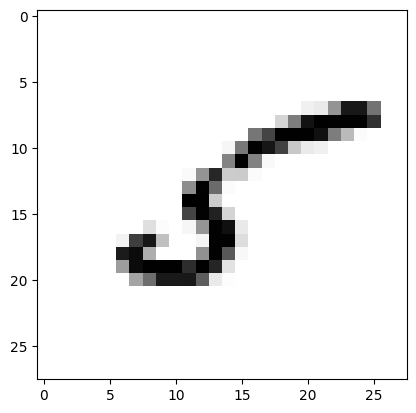

In [47]:
import matplotlib.pyplot as plt

plt.imshow(X[11, :].reshape(28, 28),
           cmap = plt.cm.Greys) # 0,11,35 are '5'

In [48]:
X[11, :]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   

In [49]:
y[11]

'5'

## 1.3 Conjuntos de treinamento e teste

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.2,
                                                    random_state = 42)

## 1.4 Classificador binário (5 ou não-5)

In [51]:
import numpy as np

y_train5 = (y_train == '5').astype(np.int64) # not-five = 0, five = 1
y_test5 = (y_test == '5').astype(np.int64) # not-five = 0, five = 1

### 1.4.1 Definindo um classicador binário

In [52]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(loss = 'log_loss',
                        max_iter = 1000,
                        random_state = 42)

### 1.4.2 Treinando com validação cruzada e medindo a performance de um classicador binário

A Acurácia (Accuracy) de um classificador pode ser definida como:

\begin{equation}
\text{Acurária} = \frac{\text{Número de predições corretas}}{\text{Número total de predições}}
\end{equation}

In [53]:
from sklearn.model_selection import cross_val_score

cv_score = cross_val_score(sgd_clf,
                           X_train,
                           y_train5,
                           cv = 3,
                           scoring = 'accuracy')
cv_score # Accuracy

array([0.94353672, 0.96983982, 0.96260581])

### 1.4.3 Definindo, treinando e medindo a performance de um classificador "dumb"

In [54]:
from sklearn.base import BaseEstimator

class Never5Classifier(BaseEstimator):
    def fit(self, X, y = None):
        pass

    def predict(self, X):
        return np.full((X.shape[0], 1), False)

nf_clf = Never5Classifier()

In [55]:
cv_score = cross_val_score(nf_clf,
                           X_train,
                           y_train5,
                           cv = 3,
                           scoring = 'accuracy')

cv_score # Accuracy is generally not the prefered performance measure for classifiers

array([0.91107302, 0.90914448, 0.90978249])

In [56]:
df['class'].value_counts(normalize=True)

,proportion
class,
1,0.112529
7,0.104186
3,0.102014
2,0.099857
9,0.099400
0,0.098614
6,0.098229
8,0.097500
4,0.097486


#### 1.4.3.1 Subamostragem aleatória

In [57]:
idx_no5 = np.argwhere(y_train5 == 0).ravel()
print(idx_no5.shape)

(50960,)


In [58]:
idx_5 = np.argwhere(y_train5 == 1).ravel()
print(idx_5.shape)

(5040,)


In [59]:
idx = np.concatenate([idx_no5[:5040], idx_5[:5040]])

X_train_subsampled = X[idx, :].copy()
y_train5_subsampled = y_train5[idx].copy()

In [60]:
cv_score = cross_val_score(sgd_clf,
                           X_train_subsampled,
                           y_train5_subsampled,
                           cv = 3,
                           scoring = 'accuracy')
cv_score

array([0.48958333, 0.51755952, 0.47708333])

In [83]:
y_train5_subsampled

array([0, 0, 0, ..., 1, 1, 1])

In [61]:
cv_score = cross_val_score(nf_clf,
                           X_train_subsampled,
                           y_train5_subsampled,
                           cv = 3,
                           scoring = 'accuracy')

cv_score

array([1. , 0.5, 0. ])

### 1.4.4 Matriz de confusão

In [62]:
from sklearn.model_selection import cross_val_predict

y_train5_pred = cross_val_predict(sgd_clf,
                                  X_train,
                                  y_train5,
                                  cv = 3)
y_train5_pred

array([0, 0, 0, ..., 0, 0, 0])

In [63]:
from sklearn.metrics import confusion_matrix

C = confusion_matrix(y_train5,
                     y_train5_pred)

C

array([[50716,   244],
       [ 2071,  2969]])

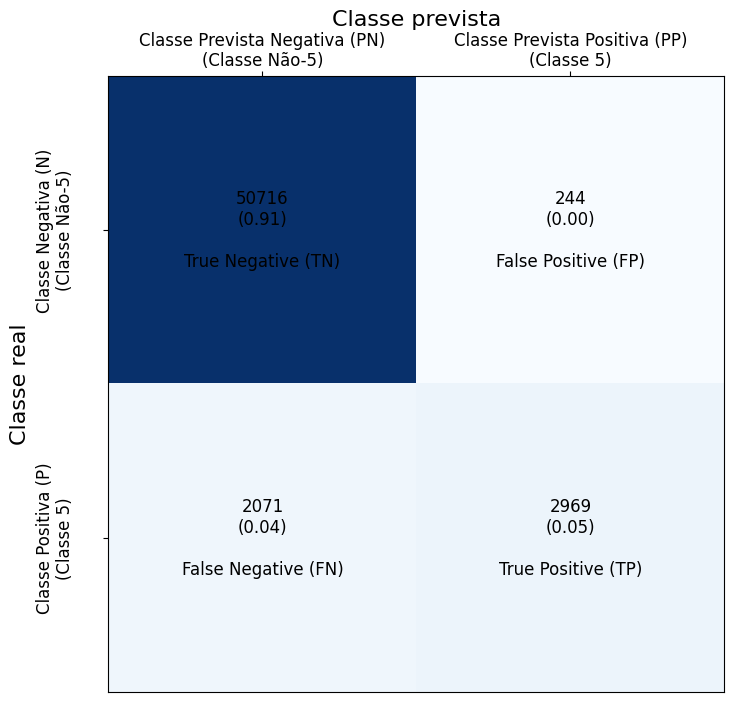

In [64]:
def plot_matrix(C):
    C_norm = C / C.sum()

    rows = ['Classe Negativa (N)\n(Classe Não-5)', 'Classe Positiva (P)\n(Classe 5)']
    columns = ['Classe Prevista Negativa (PN)\n(Classe Não-5)', 'Classe Prevista Positiva (PP)\n(Classe 5)']

    fig, ax = plt.subplots(figsize = (8, 8))

    ax.matshow(C, cmap = plt.cm.Blues) # cool

    clabel = [['True Negative (TN)', 'False Positive (FP)'],
              ['False Negative (FN)', 'True Positive (TP)']]

    clabel = np.array(clabel, dtype = object)

    for (i, j), c in np.ndenumerate(C):
        label = '{}\n({:0.2f})\n\n{}'.format(c, C_norm[i, j], clabel[i, j])
        ax.text(j, i, label, ha = 'center', va = 'center', fontsize = 12)

    ax.set_xticks(range(len(columns)))
    ax.set_yticks(range(len(rows)))
    ax.set_xticklabels(columns, ha = 'center', va = 'center', fontsize = 12)
    ax.set_yticklabels(rows, ha = 'center', va = 'center', fontsize = 12, rotation = 90)

    ax.set_xlabel('Classe prevista', fontsize = 16)
    ax.set_ylabel('Classe real', fontsize = 16)

    ax.tick_params(top = True,
                   bottom = False,
                   labeltop = True,
                   labelbottom = False)

    ax.tick_params(axis = 'x', pad = 15)
    ax.tick_params(axis = 'y', pad = 35)

    ax.xaxis.set_label_position('top')

plot_matrix(C)

![picture](https://drive.google.com/thumbnail?id=1ZOuTBkc9h9SYXhdkqVbDbS1cS4FcpvL7&sz=w800)

### 1.4.5 Precisão, Revocação e Pontuação $F_1$

A Precisão (Precision) de um classificador é definida por:

\begin{equation}
\text{Precisão} = \frac{\text{TP}}{\text{PP}} = \frac{\text{TP}}{\text{TP}+\text{FP}}.
\end{equation}

In [65]:
from sklearn.metrics import precision_score

precision_score(y_train5, y_train5_pred)

0.9240585122938064

Já a Revocação, Recall ou Sensibilidade ou True Positive Rate (TPR), é dada por:

\begin{equation}
\text{Revocação} = \frac{\text{TP}}{\text{P}} = \frac{\text{TP}}{\text{TP}+\text{FN}}.
\end{equation}

In [66]:
from sklearn.metrics import recall_score

recall_score(y_train5, y_train5_pred)

0.5890873015873016

Nesse contexto, a Acurácia pode ser rescrita como:

\begin{equation}
\text{Acurácia} = \frac{\text{TP}+\text{TN}}{\text{P}+\text{N}}.
\end{equation}

In [67]:
from sklearn.metrics import accuracy_score

accuracy_score(y_train5, y_train5_pred)

0.9586607142857143

Finalmente, definimos a pontuação $F_1$ ($F_1$-score), a fim de analisar um classificador através de uma única métrica, como a média harmônica da precisão e revocação:

\begin{equation}
F_1 = \frac{2}{\displaystyle\frac{1}{\text{Precisão}}+\displaystyle\frac{1}{\text{Revocação}}}
=
\frac{\text{TP}}{\text{TP}+\displaystyle\frac{\text{FN}+\text{FP}}{2}}.
\end{equation}

In [68]:
from sklearn.metrics import f1_score

f1_score(y_train5, y_train5_pred)

0.7194959408699867

![picture](https://drive.google.com/thumbnail?id=1DoRHTuk8dprUtdaR477zsMUoVMRkTLWP&sz=w800)

### 1.4.6 Trade-off Precisão/Revocação

![picture](https://drive.google.com/thumbnail?id=1zY7x-usRp4QT60HXya4De21SOXqdyBqy&sz=w800)

In [69]:
y_score = cross_val_predict(sgd_clf,
                            X_train,
                            y_train5,
                            cv = 3,
                            method = 'decision_function')

In [70]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train5, y_score)

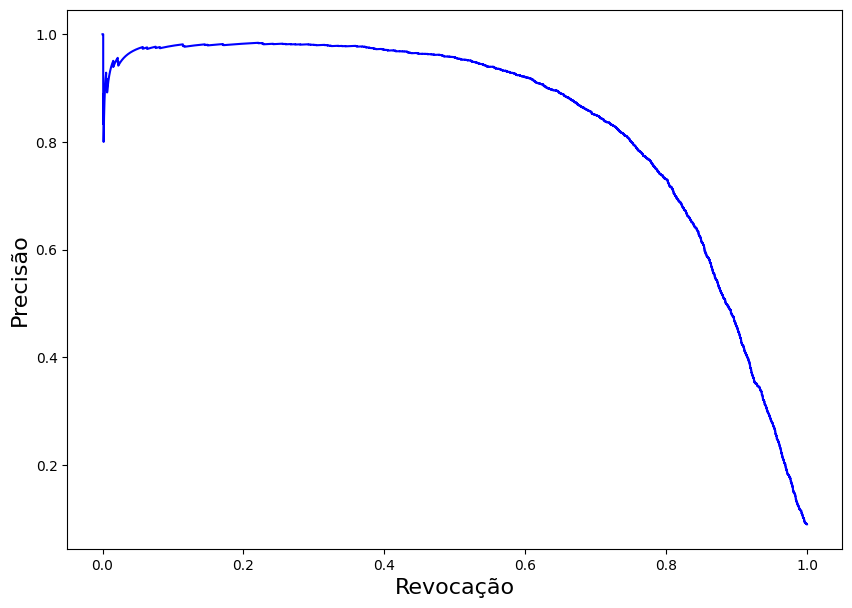

In [71]:
def plot_precision_vs_recall(precisions, recalls):

    fig, ax = plt.subplots(figsize = (10, 7))

    ax.plot(recalls,
            precisions,
            'b-')

    ax.set_xlabel('Revocação', fontsize = 16)
    ax.set_ylabel('Precisão', fontsize = 16)

plot_precision_vs_recall(precisions, recalls)

/tmp/ipykernel_23965/38832816.py:1: RuntimeWarning: divide by zero encountered in divide
  f1_scores = 2 / (1 / precisions + 1 / recalls)


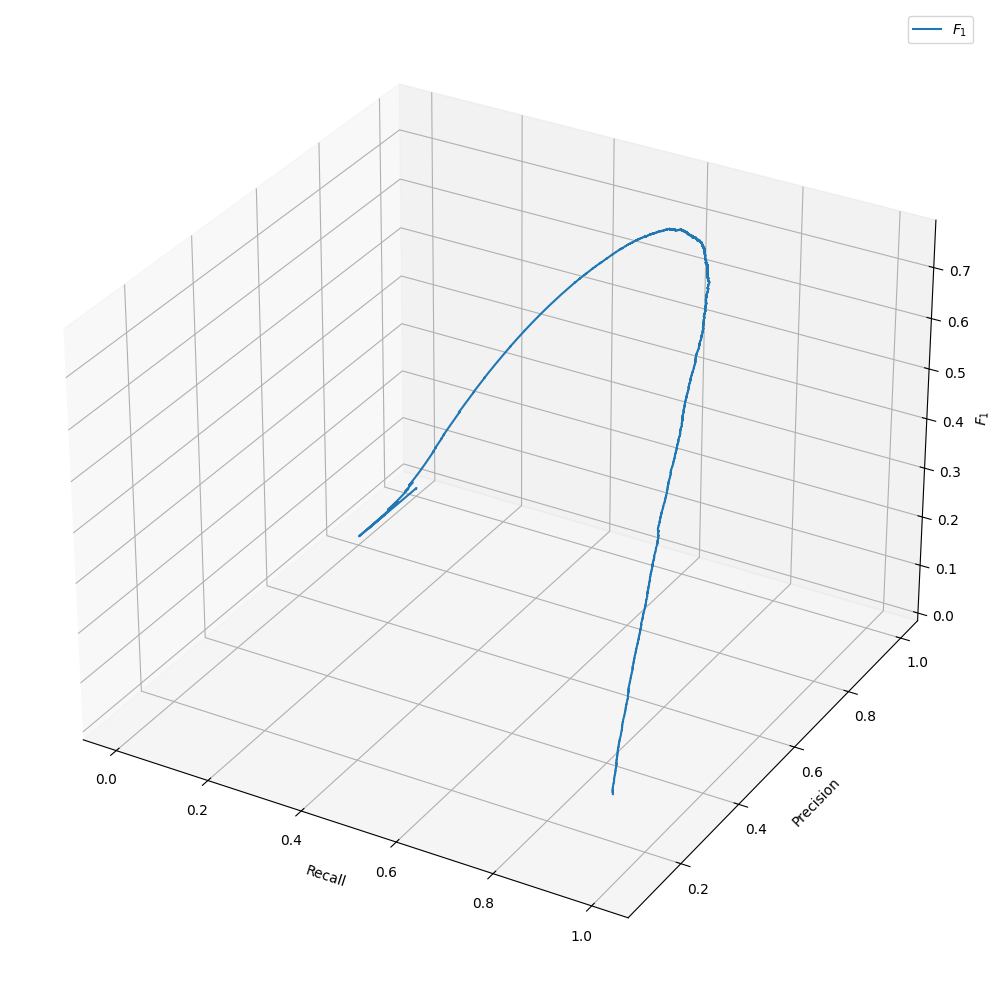

In [72]:
f1_scores = 2 / (1 / precisions + 1 / recalls)
fig, ax = plt.subplots(figsize = (10, 10),
                       subplot_kw = {'projection': '3d',
                                     'computed_zorder': False})

ax.plot(recalls,
        precisions,
        f1_scores,
        label = '$F_1$')

ax.legend()

ax.set(xlabel = 'Recall',
       ylabel = 'Precision',
       zlabel = '$F_1$')

plt.tight_layout()

In [73]:
idx = (precisions >= 0.90).argmax()
print(idx)
threshold_for_90_precision = thresholds[idx]
threshold_for_90_precision

52465


np.float64(-897.2296189201473)

In [74]:
y_train5_pred_90 = (y_score >= threshold_for_90_precision).astype(np.int64)

In [75]:
precision_score(y_train5, y_train5_pred_90)

0.9001414427157002

In [76]:
recall_score(y_train5, y_train5_pred_90)

0.6313492063492063

## 1.4.7 Curva ROC

A curva Característica de Operação do Receptor, ou Receiver Operating Characteristic (ROC), é defina pelo gráfico da Revocação versus a False Positive Rate (FPR). Note que

\begin{equation}
FPR = 1 - TNR,
\end{equation}

onde TNR é a True Negative Rate, também conhecida como especificidade ou fall-out.

In [77]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train5, y_score) # fpr = false positive rate, tpr = true positive rate

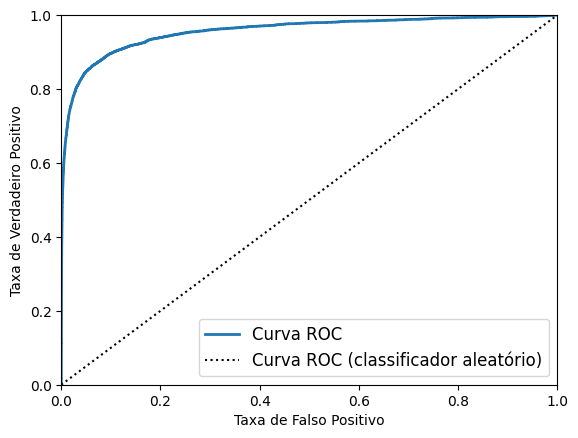

In [78]:
def plot_roc_curve(fpr, tpr):
    plt.plot(fpr,
             tpr,
             lw = 2,
             label ='Curva ROC')

    plt.plot([0, 1],
             [0, 1],
             'k:',
             label = 'Curva ROC (classificador aleatório)')

    plt.xlabel('Taxa de Falso Positivo')
    plt.ylabel('Taxa de Verdadeiro Positivo')
    plt.axis([0, 1, 0, 1])

    plt.legend(loc = 'lower right',
            fontsize = 12)

plot_roc_curve(fpr, tpr)

#### 1.4.7.1 Área sob a Curva ou Area Under the Curve (AUC)



In [79]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_train5, y_score)

np.float64(0.9568205883543893)

Lembrete:

- Sempre que a classe positiva for rara ou quando os falsos positivos forem mais importantes que os falsos negativos, use a curva de Precisão/Revocação. Caso contrário, use a curva ROC.

In [80]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

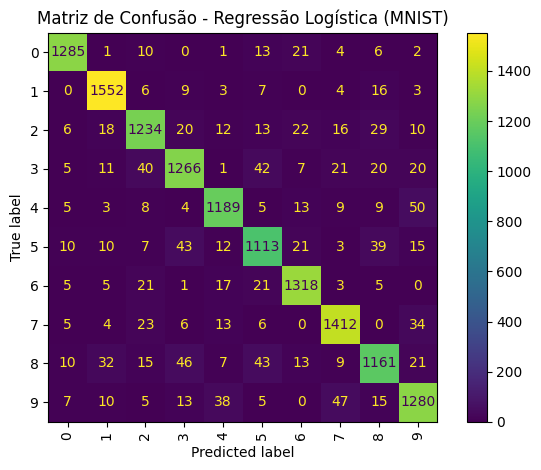

In [81]:
y_pred = log_reg.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_reg.classes_)
disp.plot(cmap='viridis', xticks_rotation='vertical')
plt.title("Matriz de Confusão - Regressão Logística (MNIST)")
plt.tight_layout()
plt.show()

In [82]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score
)
report = classification_report(y_test, y_pred)
print("=== Classification Report ===")
print(report)

# 8. Acurácia geral
accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia geral: {accuracy:.4f}")

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      1343
           1       0.94      0.97      0.96      1600
           2       0.90      0.89      0.90      1380
           3       0.90      0.88      0.89      1433
           4       0.92      0.92      0.92      1295
           5       0.88      0.87      0.88      1273
           6       0.93      0.94      0.94      1396
           7       0.92      0.94      0.93      1503
           8       0.89      0.86      0.87      1357
           9       0.89      0.90      0.90      1420

    accuracy                           0.92     14000
   macro avg       0.91      0.91      0.91     14000
weighted avg       0.91      0.92      0.91     14000

Acurácia geral: 0.9150
